In [ ]:
# ============================================================
# STEP 2 - IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# STEP 3 - UPLOAD DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving Cars Datasets 2025.csv to Cars Datasets 2025.csv


In [ ]:
# ============================================================
# STEP 4 - LOAD DATASET
# ============================================================

df = pd.read_csv(
    "Cars Datasets 2025.csv",
    encoding="latin1"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1218
Columns: 11


In [ ]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [ ]:
df.tail()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219  302 hp,200 km/h,6.0  8.1 sec,"$29,000  $43,000",Hybrid / Plug-in,5,221  400 Nm


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1218
Columns: 11


In [ ]:
print(df.columns.tolist())

['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices', 'Fuel Types', 'Seats', 'Torque']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


In [ ]:
df.describe(include="all")

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,Mistral,I4,1984 cc,355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72


In [ ]:
# ============================================================
# MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

print(missing_values)

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


In [ ]:
missing_values[missing_values > 0]

,0
CC/Battery Capacity,3
Performance(0 - 100 )KM/H,6
Torque,1


In [ ]:
# ============================================================
# DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 4


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1214, 11)


In [ ]:
# ============================================================
# STEP 8 - COMPLETE DATA CLEANING
# ============================================================

# Remove extra spaces from column names
df.columns = df.columns.str.strip()


# ------------------------------------------------------------
# CLEAN TEXT COLUMNS
# ------------------------------------------------------------

df["Company Names"] = (
    df["Company Names"]
    .astype(str)
    .str.strip()
    .str.title()
)

df["Cars Names"] = (
    df["Cars Names"]
    .astype(str)
    .str.strip()
)

df["Engines"] = (
    df["Engines"]
    .astype(str)
    .str.strip()
)

df["Fuel Types"] = (
    df["Fuel Types"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ------------------------------------------------------------
# FUNCTION FOR NUMERICAL VALUES AND RANGES
# ------------------------------------------------------------

def convert_range_to_average(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    value = value.replace("hp", "")
    value = value.replace("nm", "")
    value = value.replace("sec", "")
    value = value.replace("km/h", "")
    value = value.replace("cc", "")

    value = value.replace(",", "")
    value = value.replace(" ", "")

    if "-" in value:

        try:
            numbers = value.split("-")

            first = float(numbers[0])
            second = float(numbers[1])

            return (first + second) / 2

        except:
            return np.nan

    try:
        return float(value)

    except:
        return np.nan


# ------------------------------------------------------------
# HORSEPOWER
# ------------------------------------------------------------

df["HorsePower"] = df["HorsePower"].apply(
    convert_range_to_average
)


# ------------------------------------------------------------
# TOTAL SPEED
# ------------------------------------------------------------

df["Total Speed"] = (
    df["Total Speed"]
    .astype(str)
    .str.lower()
    .str.replace("km/h", "", regex=False)
    .str.replace("kmph", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Total Speed"] = pd.to_numeric(
    df["Total Speed"],
    errors="coerce"
)


# ------------------------------------------------------------
# 0-100 PERFORMANCE
# ------------------------------------------------------------

performance_column = "Performance(0 - 100 )KM/H"

df[performance_column] = (
    df[performance_column]
    .apply(convert_range_to_average)
)


# ------------------------------------------------------------
# CC / BATTERY CAPACITY
# ------------------------------------------------------------

df["CC_Battery"] = (
    df["CC/Battery Capacity"]
    .astype(str)
    .str.lower()
    .str.replace("cc", "", regex=False)
    .str.replace("kw", "", regex=False)
    .str.replace("kwh", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["CC_Battery"] = pd.to_numeric(
    df["CC_Battery"],
    errors="coerce"
)


# ------------------------------------------------------------
# TORQUE
# ------------------------------------------------------------

df["Torque_Nm"] = (
    df["Torque"]
    .apply(convert_range_to_average)
)


# ------------------------------------------------------------
# SEATS
# ------------------------------------------------------------

def clean_seats(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    value = value.replace("–", "-")
    value = value.replace("—", "-")

    if "+" in value:

        try:
            numbers = value.split("+")
            return sum(float(x) for x in numbers)

        except:
            return np.nan

    if "-" in value:

        try:
            numbers = value.split("-")

            first = float(numbers[0])
            second = float(numbers[1])

            return (first + second) / 2

        except:
            return np.nan

    try:
        return float(value)

    except:
        return np.nan


df["Seats_Clean"] = df["Seats"].apply(
    clean_seats
)


# ------------------------------------------------------------
# CAR PRICE
# ------------------------------------------------------------

def clean_price(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    value = value.replace("$", "")
    value = value.replace(",", "")
    value = value.replace(" ", "")

    if "-" in value:

        try:
            numbers = value.split("-")

            first = float(numbers[0])
            second = float(numbers[1])

            return (first + second) / 2

        except:
            return np.nan

    try:
        return float(value)

    except:
        return np.nan


df["Price"] = df["Cars Prices"].apply(
    clean_price
)


# ------------------------------------------------------------
# HANDLE MISSING NUMERICAL VALUES
# ------------------------------------------------------------

numeric_columns = [
    "HorsePower",
    "Total Speed",
    performance_column,
    "CC_Battery",
    "Torque_Nm",
    "Seats_Clean",
    "Price"
]

for column in numeric_columns:

    df[column] = df[column].fillna(
        df[column].median()
    )


# ------------------------------------------------------------
# HANDLE MISSING CATEGORICAL VALUES
# ------------------------------------------------------------

categorical_columns = [
    "Company Names",
    "Cars Names",
    "Engines",
    "Fuel Types"
]

for column in categorical_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].mode()[0]
        )


print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [ ]:
display(df.head(10))

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,CC_Battery,Torque_Nm,Seats_Clean,Price
0,Ferrari,SF90 STRADALE,V8,3990 cc,963.0,340.0,2.5,"$1,100,000",Plug In Hyrbrid,2,800 Nm,3990.0,800.0,2.0,1100000.0
1,Rolls Royce,PHANTOM,V12,6749 cc,563.0,250.0,5.3,"$460,000",Petrol,5,900 Nm,6749.0,900.0,5.0,460000.0
2,Ford,KA+,1.2L Petrol,"1,200 cc",77.5,165.0,10.5,"$12,000-$15,000",Petrol,5,100 - 140 Nm,1200.0,120.0,5.0,13500.0
3,Mercedes,GT 63 S,V8,"3,982 cc",630.0,250.0,3.2,"$161,000",Petrol,4,900 Nm,3982.0,900.0,4.0,161000.0
4,Audi,AUDI R8 Gt,V10,"5,204 cc",602.0,320.0,3.6,"$253,290",Petrol,2,560 Nm,5204.0,560.0,2.0,253290.0
5,Bmw,Mclaren 720s,V8,"3,994 cc",710.0,341.0,2.9,"$499,000",Petrol,2,770 Nm,3994.0,770.0,2.0,499000.0
6,Aston Martin,VANTAGE F1,V8,"3,982 cc",656.0,314.0,3.6,"$193,440",Petrol,2,685 Nm,3982.0,685.0,2.0,193440.0
7,Bentley,Continental GT Azure,V8,"3,996 cc",550.0,318.0,4.0,"$311,000",Petrol,4,900 Nm,3996.0,900.0,4.0,311000.0
8,Lamborghini,VENENO ROADSTER,V12,"6,498 cc",750.0,356.0,2.9,"$4,500,000",Petrol,2,690 Nm,6498.0,690.0,2.0,4500000.0
9,Ferrari,F8 TRIBUTO,V8,"3,900 cc",710.0,340.0,2.9,"$280,000",Petrol,2,770 Nm,3900.0,770.0,2.0,280000.0


In [ ]:
df.describe()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,CC_Battery,Torque_Nm,Seats_Clean,Price
count,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1.214000e+03
mean,305.481466,216.499176,7.567751,2982.574959,507.450577,4.853377,1.383136e+05
std,218.726557,53.003441,3.304854,1708.271706,1050.300898,1.497979,7.118983e+05
min,26.000000,80.000000,1.900000,360.000000,45.000000,1.000000,4.000000e+03
25%,155.000000,180.000000,5.300000,1984.000000,250.000000,4.000000,2.800000e+04
50%,255.000000,200.000000,7.100000,2500.000000,371.500000,5.000000,4.280750e+04
75%,400.000000,250.000000,9.500000,3500.000000,560.000000,5.000000,7.000000e+04
max,2488.000000,500.000000,35.000000,16100.000000,15590.000000,20.000000,1.800000e+07


In [ ]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "cleaned_cars_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
from google.colab import files

files.download("cleaned_cars_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df[numeric_columns].describe()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,CC_Battery,Torque_Nm,Seats_Clean,Price
count,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1214.000000,1.214000e+03
mean,305.481466,216.499176,7.567751,2982.574959,507.450577,4.853377,1.383136e+05
std,218.726557,53.003441,3.304854,1708.271706,1050.300898,1.497979,7.118983e+05
min,26.000000,80.000000,1.900000,360.000000,45.000000,1.000000,4.000000e+03
25%,155.000000,180.000000,5.300000,1984.000000,250.000000,4.000000,2.800000e+04
50%,255.000000,200.000000,7.100000,2500.000000,371.500000,5.000000,4.280750e+04
75%,400.000000,250.000000,9.500000,3500.000000,560.000000,5.000000,7.000000e+04
max,2488.000000,500.000000,35.000000,16100.000000,15590.000000,20.000000,1.800000e+07


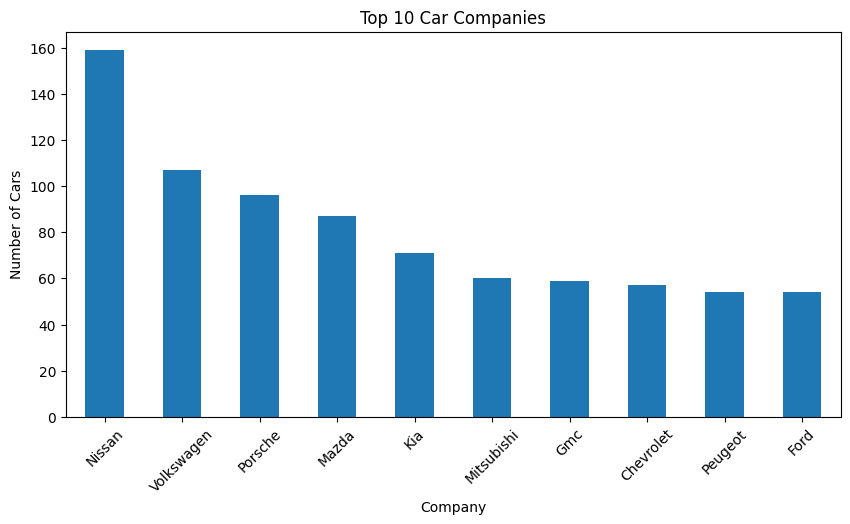

In [ ]:
company_counts = (
    df["Company Names"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

company_counts.plot(kind="bar")

plt.title("Top 10 Car Companies")
plt.xlabel("Company")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

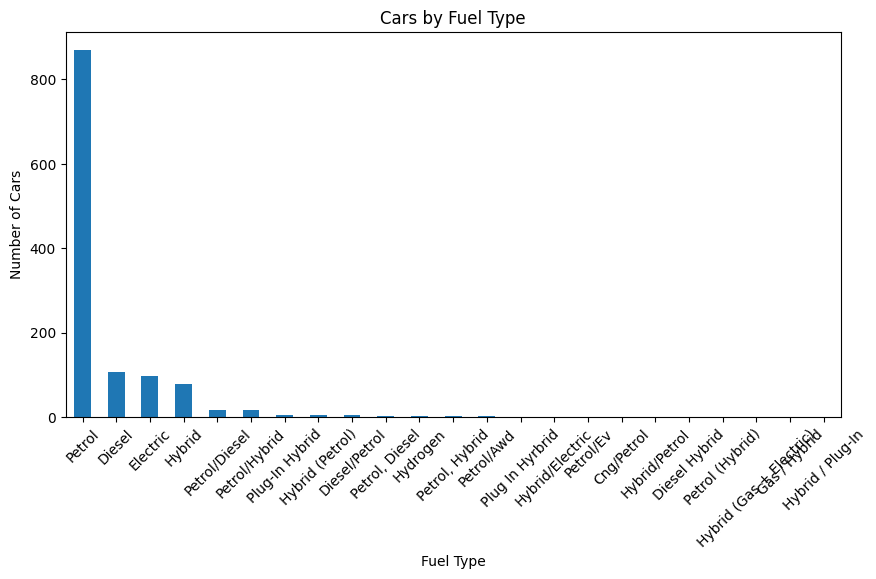

In [ ]:
fuel_counts = df["Fuel Types"].value_counts()

plt.figure(figsize=(10,5))

fuel_counts.plot(kind="bar")

plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

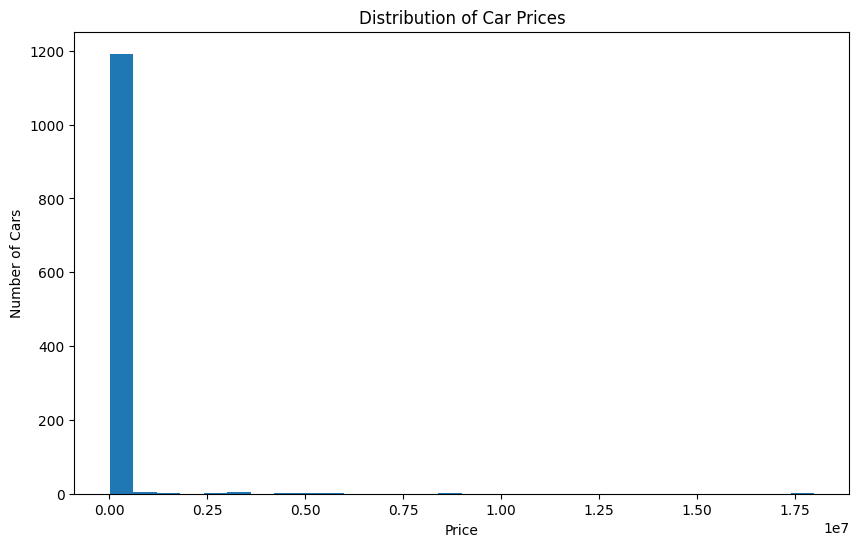

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Price"],
    bins=30
)

plt.title("Distribution of Car Prices")

plt.xlabel("Price")

plt.ylabel("Number of Cars")

plt.show()

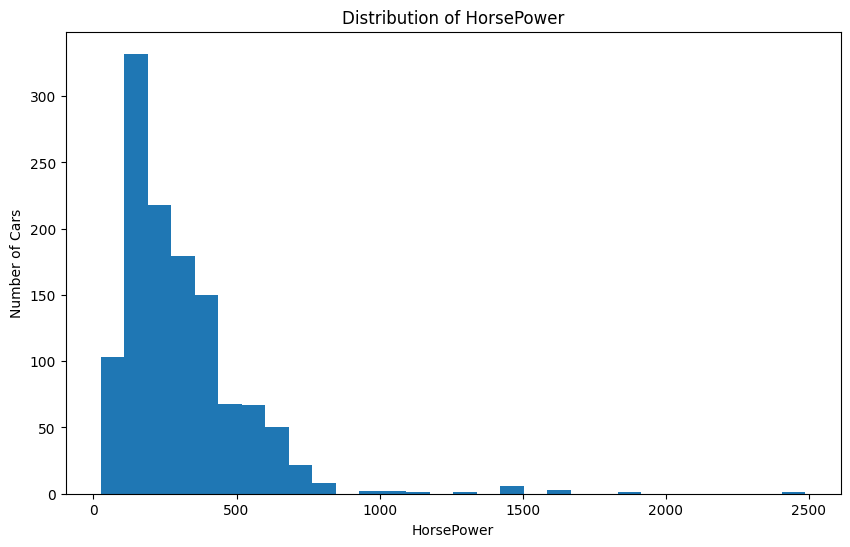

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df["HorsePower"],
    bins=30
)

plt.title("Distribution of HorsePower")

plt.xlabel("HorsePower")

plt.ylabel("Number of Cars")

plt.show()

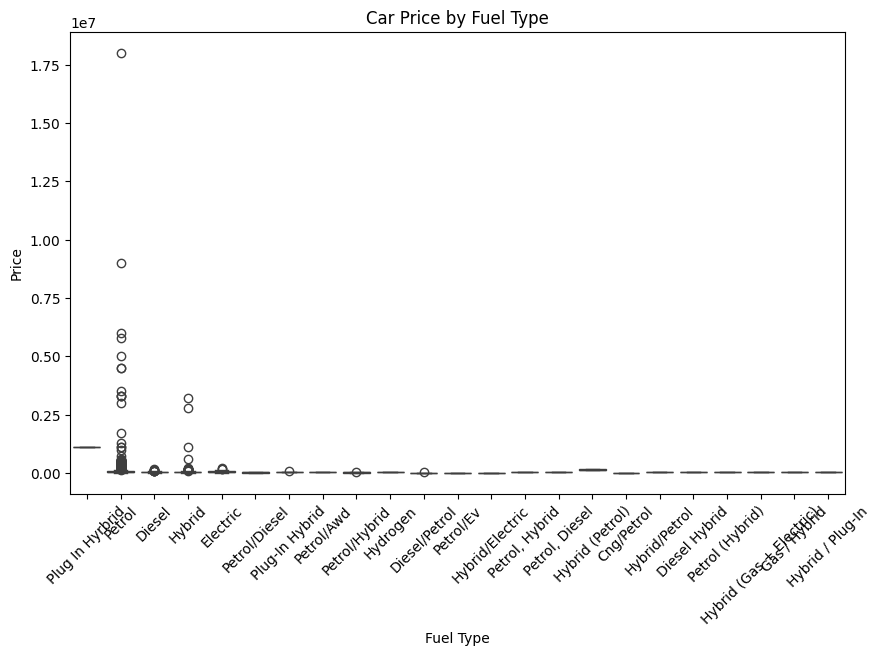

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Fuel Types",
    y="Price"
)

plt.title("Car Price by Fuel Type")

plt.xlabel("Fuel Type")

plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

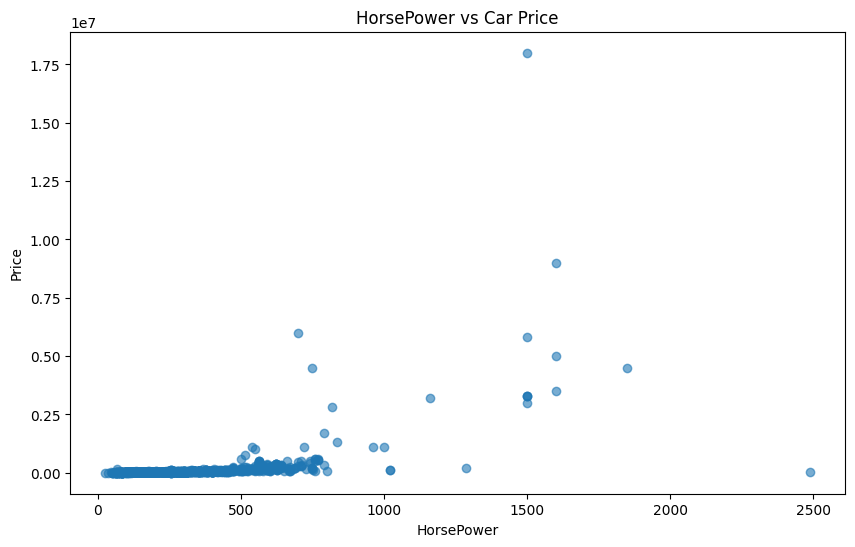

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["HorsePower"],
    df["Price"],
    alpha=0.6
)

plt.title("HorsePower vs Car Price")

plt.xlabel("HorsePower")

plt.ylabel("Price")

plt.show()

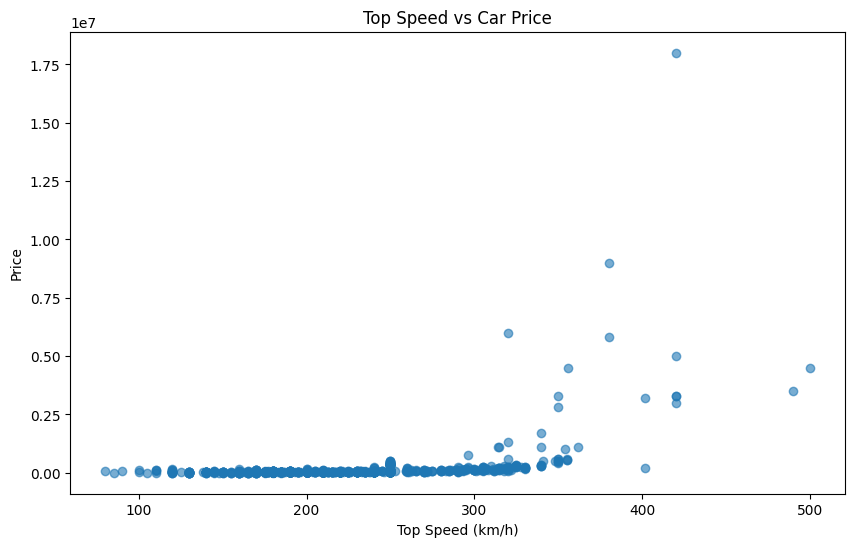

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Total Speed"],
    df["Price"],
    alpha=0.6
)

plt.title("Top Speed vs Car Price")

plt.xlabel("Top Speed (km/h)")

plt.ylabel("Price")

plt.show()

In [ ]:
correlation_columns = [
    "HorsePower",
    "Total Speed",
    performance_column,
    "CC_Battery",
    "Torque_Nm",
    "Seats_Clean",
    "Price"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

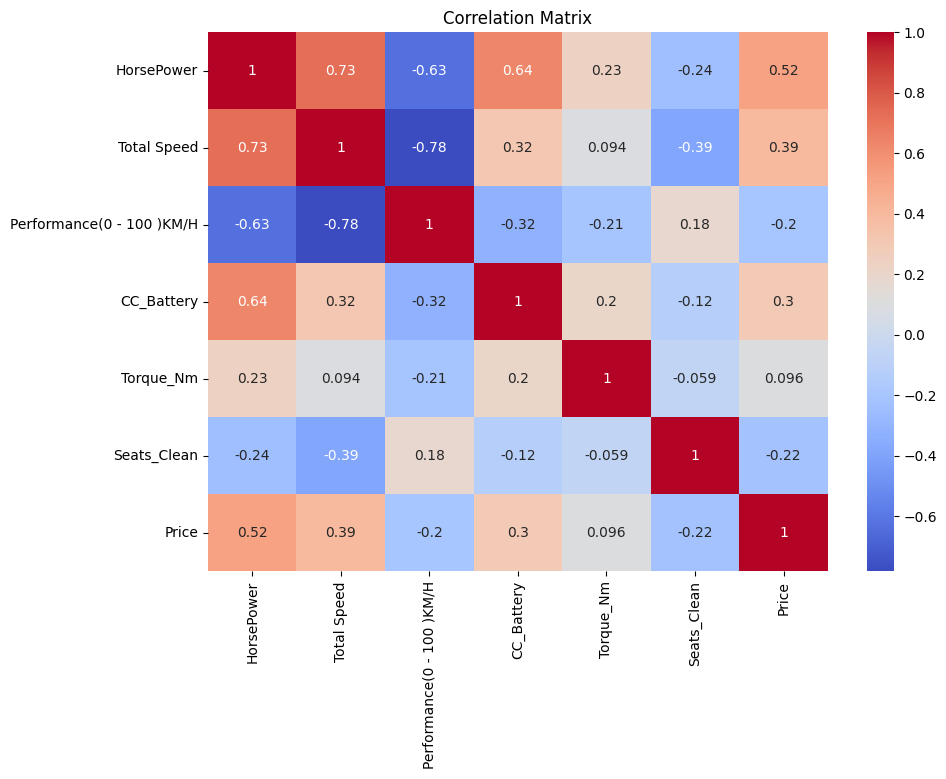

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
price_correlation = (
    correlation_matrix["Price"]
    .sort_values(ascending=False)
)

print(price_correlation)

Price                        1.000000
HorsePower                   0.517064
Total Speed                  0.388105
CC_Battery                   0.295380
Torque_Nm                    0.095639
Performance(0 - 100 )KM/H   -0.201862
Seats_Clean                 -0.222204
Name: Price, dtype: float64


In [ ]:
df["Power_Speed_Ratio"] = (
    df["HorsePower"] /
    df["Total Speed"]
)

In [ ]:
df[
    [
        "HorsePower",
        "Total Speed",
        "Power_Speed_Ratio"
    ]
].head()

,HorsePower,Total Speed,Power_Speed_Ratio
0,963.0,340.0,2.832353
1,563.0,250.0,2.252000
2,77.5,165.0,0.469697
3,630.0,250.0,2.520000
4,602.0,320.0,1.881250


In [ ]:
features = [
    "Company Names",
    "Fuel Types",
    "HorsePower",
    "Total Speed",
    performance_column,
    "CC_Battery",
    "Seats_Clean",
    "Torque_Nm"
]

X = df[features]

y = df["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (971, 8)
Testing data: (243, 8)


In [ ]:
categorical_features = [
    "Company Names",
    "Fuel Types"
]

numerical_features = [
    "HorsePower",
    "Total Speed",
    performance_column,
    "CC_Battery",
    "Seats_Clean",
    "Torque_Nm"
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [ ]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

In [ ]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression")
print("-----------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
-----------------------------
MAE : 65192.379491073974
RMSE: 112031.26223882507
R²  : 0.9139985318351983


In [ ]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

In [ ]:
# ============================================================
# STEP 32 - COMPARE MODELS
# ============================================================

# Calculate metrics directly from actual and predicted values

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


# Create comparison table

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        mae_linear,
        mae_rf
    ],

    "RMSE": [
        rmse_linear,
        rmse_rf
    ],

    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})


display(model_results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,65192.379491,112031.262239,0.913999
1,Random Forest,39577.006416,209555.481392,0.699098


In [ ]:
# ============================================================
# STEP 33 - CROSS VALIDATION
# ============================================================

cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores")
print("----------------------------")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("----------------------------")
print("Average Cross-Validation R²:",
      round(cv_scores.mean(), 4))

Cross-Validation R² Scores
----------------------------
Fold 1: 0.3488
Fold 2: -6.1235
Fold 3: -19.5681
Fold 4: 0.3406
Fold 5: 0.0806
----------------------------
Average Cross-Validation R²: -4.9843


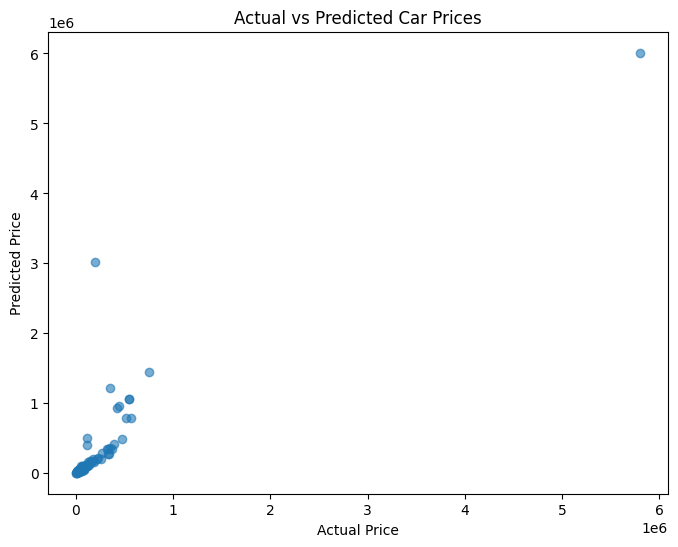

In [ ]:
# ============================================================
# STEP 34 - ACTUAL VS PREDICTED PRICES
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

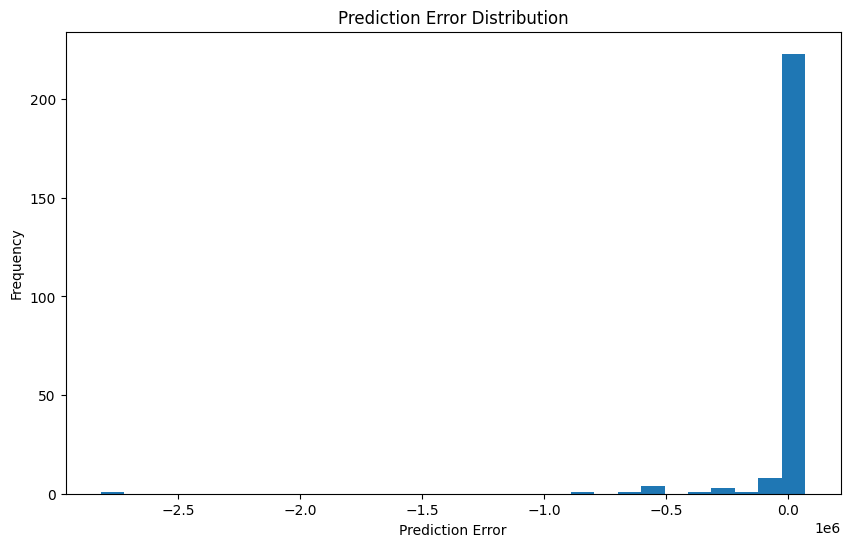

In [ ]:
# ============================================================
# STEP 35 - PREDICTION ERROR DISTRIBUTION
# ============================================================

prediction_errors = y_test - y_pred_rf

plt.figure(figsize=(10, 6))

plt.hist(
    prediction_errors,
    bins=30
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ============================================================
# STEP 36 - SAVE THE TRAINED MODEL
# ============================================================

import joblib

joblib.dump(
    random_forest_model,
    "car_price_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
# ============================================================
# STEP 37 - DOWNLOAD MODEL
# ============================================================

from google.colab import files

files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 38 - FINAL MODEL RESULTS
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_rf
    ]
})

display(final_results)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,65192.379491,112031.262239,0.913999
1,Random Forest,39577.006416,209555.481392,0.699098


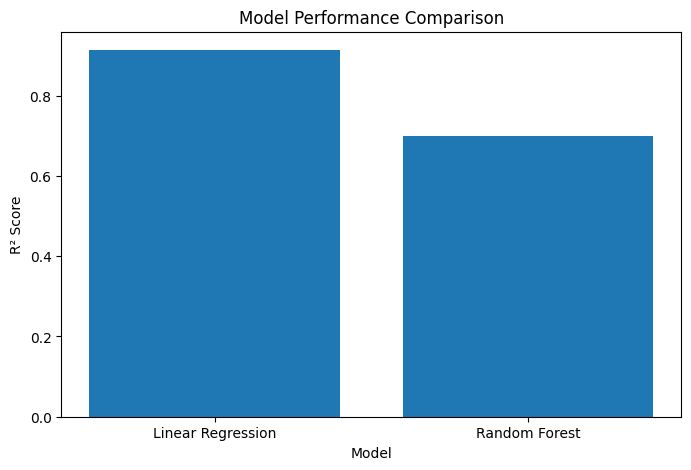

In [ ]:
# ============================================================
# STEP 39 - MODEL R2 COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Model"],
    final_results["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.show()

In [ ]:
# ============================================================
# STEP 40 - SAVE MODEL RESULTS
# ============================================================

final_results.to_csv(
    "model_results.csv",
    index=False
)

print("Model results saved successfully!")

Model results saved successfully!


In [ ]:
from google.colab import files

files.download("model_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 41 - SAVE FINAL DATASET
# ============================================================

df.to_csv(
    "final_car_dataset.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [ ]:
from google.colab import files

files.download("final_car_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# RETRAIN RANDOM FOREST MODEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

features = [
    "Company Names",
    "Fuel Types",
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "CC_Battery",
    "Seats_Clean",
    "Torque_Nm"
]

X = df[features]
y = df["Price"]

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# CATEGORICAL AND NUMERICAL FEATURES
# ------------------------------------------------------------

categorical_features = [
    "Company Names",
    "Fuel Types"
]

numerical_features = [
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "CC_Battery",
    "Seats_Clean",
    "Torque_Nm"
]

# ------------------------------------------------------------
# PREPROCESSOR
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# ------------------------------------------------------------
# RANDOM FOREST MODEL
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

random_forest_model.fit(
    X_train,
    y_train
)

# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

y_pred_rf = random_forest_model.predict(X_test)

# ------------------------------------------------------------
# MODEL EVALUATION
# ------------------------------------------------------------

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("======================================")
print("RANDOM FOREST MODEL RESULTS")
print("======================================")

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

joblib.dump(
    random_forest_model,
    "car_price_model_v2.pkl"
)

print("\nModel saved successfully!")
print("File: car_price_model_v2.pkl")

RANDOM FOREST MODEL RESULTS
MAE : 39577.00641581099
RMSE: 209555.48139152708
R²  : 0.6990977344882323

Model saved successfully!
File: car_price_model_v2.pkl


In [ ]:
from google.colab import files

files.download("car_price_model_v2.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>